In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
df = pd.read_csv('AB_NYC_2019.csv')

In [155]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [156]:
df['last_review'] = df['last_review'].fillna('No reviews')
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

In [157]:
df.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [158]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,10/19/2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,5/21/2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,No reviews,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,7/5/2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,11/19/2018,0.10,1,0


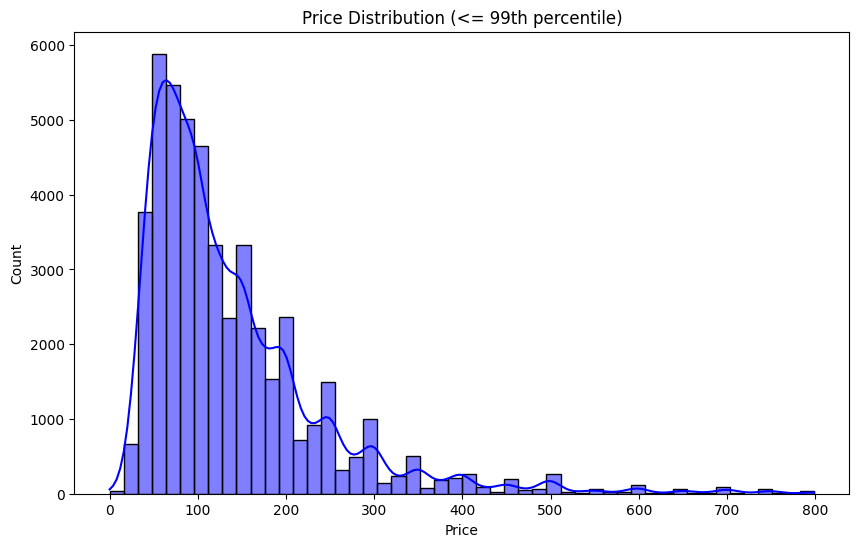

In [159]:
plt.figure(figsize=(10, 6))
#the outliers are to0 extreme, so I capped them at the 99th percentile
price_cap = df["price"].quantile(0.99)
sns.histplot(df.loc[df["price"] <= price_cap, "price"], bins=50, kde=True, color="blue")
plt.title("Price Distribution (<= 99th percentile)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### Insight: Price Distribution
1. Most listings cluster in the lower price range, indicating a right-skewed distribution.
2. A small number of very expensive listings create a long upper tail.
3. Using the 99th percentile cap makes the typical market pattern easier to see.

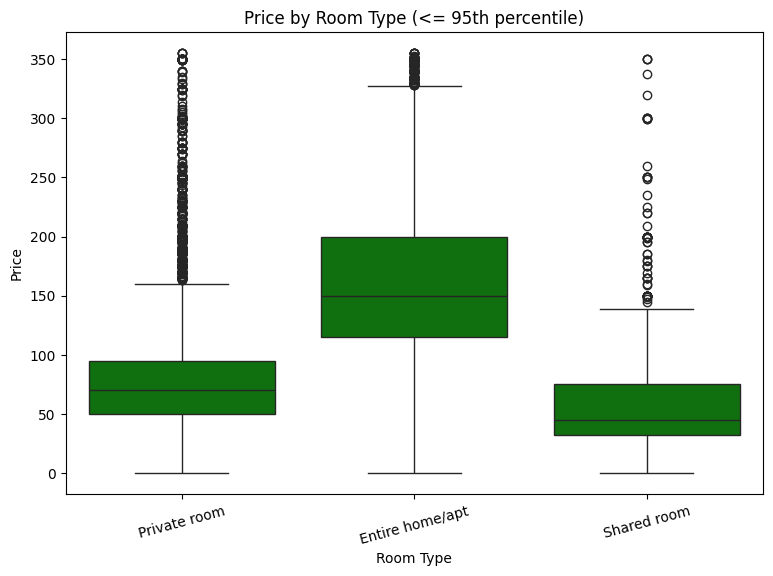

In [160]:
plt.figure(figsize=(9, 6))
price_cap = df["price"].quantile(0.95)
sns.boxplot(data=df[df["price"] <= price_cap], x="room_type", y="price", color="green")
plt.title("Price by Room Type (<= 95th percentile)")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.xticks(rotation=15)
plt.show()

### Insight: Price by Room Type
1. Entire home/apt listings have the highest typical prices compared with private/shared rooms.
2. Private rooms are generally cheaper, suggesting a lower-cost segment of the market.
3. Even after capping at the 95th percentile, price variability remains high across room types.

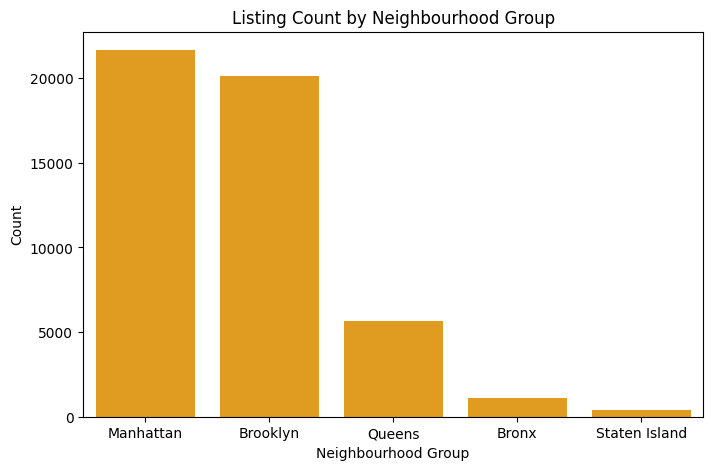

In [161]:
plt.figure(figsize=(8, 5))
order = df["neighbourhood_group"].value_counts().index
sns.countplot(data=df, x="neighbourhood_group", order=order, color="orange")
plt.title("Listing Count by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count")
plt.show()

### Insight: Listing Count by Neighbourhood Group
1. Manhattan and Brooklyn contain the largest share of listings, showing supply concentration in these areas.
2. Queens has a moderate listing volume, while Bronx and Staten Island are much lower.
3. Listing availability is uneven across boroughs, which can influence competition and pricing patterns.